**1. Imports and Environment Setup**

In [2]:
# Comprehensive AI4I IPMEF implementation aligned with revised RQ1-RQ3.



import os, sys, json, time, platform, tempfile, warnings
from pathlib import Path
import joblib, psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, brier_score_loss, log_loss

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from xgboost import XGBClassifier

# Imbalanced learning utilities
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')

**2. Output directory setup**

In [3]:
# Output directory structure
OUTPUT_DIR = Path('ai4i_ipmef_final_outputs')
FIGURE_DIR = OUTPUT_DIR / 'figures'
MODEL_DIR = OUTPUT_DIR / 'models'

# Create required directories
for d in [OUTPUT_DIR, FIGURE_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

**3. Experiment Configuration**

In [4]:
# Experiment configuration and reproducibility settings
SEEDS = [42,100,2024,1234,9999,7,21,77,314,2025,11,55,88,144,512,777,909,1337,2048,4096]

FP_PENALTY = 1.0      # False Positive penalty
FN_PENALTY = 10.0     # False Negative penalty

# Corruption experiment settings
CORRUPTION_REPEATS = 5
NOISE_LEVELS = [0.05,0.10,0.20,0.30]
MISSING_LEVELS = [0.05,0.10,0.20,0.30]
OFFSET_LEVELS = [0.05,0.10,0.20,0.30]
OUTLIER_LEVELS = [0.01,0.03,0.05,0.10]
OUTLIER_MAGNITUDE_SD = 4.0

# Latency benchmarking settings
LATENCY_WARMUPS = 5
LATENCY_REPEATS = 30
SINGLE_SAMPLE_LATENCY_REPEATS = 100

# AI4I dataset URL
DATA_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv'
# Ensure reproducibility for Python hashing
os.environ['PYTHONHASHSEED'] = str(SEEDS[0])

**4. Environment Logging**

In [5]:
# Log environment details for reproducibility
environment = {
    'python_version': sys.version,
    'platform': platform.platform(),
    'processor': platform.processor(),
    'logical_cpu_count': psutil.cpu_count(logical=True),
    'physical_cpu_count': psutil.cpu_count(logical=False),
    'ram_gb': round(psutil.virtual_memory().total/(1024**3), 2),
    'numpy_version': np.__version__,
    'pandas_version': pd.__version__,
}
experiment_configuration = {
    'seeds': SEEDS,
    'fp_penalty': FP_PENALTY,
    'fn_penalty': FN_PENALTY,
    'corruption_repeats': CORRUPTION_REPEATS,
    'noise_levels': NOISE_LEVELS,
    'missing_levels': MISSING_LEVELS,
    'offset_levels': OFFSET_LEVELS,
    'outlier_levels': OUTLIER_LEVELS,
    'outlier_magnitude_sd': OUTLIER_MAGNITUDE_SD,
    'latency_warmups': LATENCY_WARMUPS,
    'latency_repeats': LATENCY_REPEATS,
    'single_sample_latency_repeats': SINGLE_SAMPLE_LATENCY_REPEATS,
    'data_url': DATA_URL,
    'interpretation': {
        'sensor_offset': 'Static sensor bias, not temporal drift.',
        'operational_cost': 'Assumed asymmetric penalty units, not monetary cost.',
        'composite_robustness': 'Adapted secondary summary; condition-level outputs remain primary.',
        'fixed_weight_scenarios': 'Preliminary decision baseline; final method is in Notebook 3.',
    },
}

# Save environment metadata
with open(OUTPUT_DIR/'execution_environment.json','w',encoding='utf-8') as f:
    json.dump(environment,f,indent=2)

with open(OUTPUT_DIR/'experiment_configuration.json','w',encoding='utf-8') as f:
    json.dump(experiment_configuration,f,indent=2)

print('Output directory:', OUTPUT_DIR.resolve())
print(pd.DataFrame([environment]).T.rename(columns={0:'Value'}))

Output directory: /content/ai4i_ipmef_final_outputs
                                                                Value
python_version      3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13....
platform                         Linux-6.6.122+-x86_64-with-glibc2.39
processor                                                      x86_64
logical_cpu_count                                                   2
physical_cpu_count                                                  1
ram_gb                                                          12.67
numpy_version                                                   2.1.3
pandas_version                                                  2.2.3


**5. Load AI4I Dataset and Remove Leakage**

In [6]:
# Load AI4I dataset and remove leakage variables
df = pd.read_csv(DATA_URL)

target_col = 'Machine failure'
leakage_cols = ['TWF','HDF','PWF','OSF','RNF']      # Known leakage indicators
identifier_cols = ['UDI','Product ID']              # Non-informative identifiers

# Remove leakage and identifiers
X = df.drop(columns=identifier_cols+leakage_cols+[target_col])
y = df[target_col].astype(int)

categorical_features = ['Type']
numeric_features = [c for c in X.columns if c not in categorical_features]

print('Dataset shape:',df.shape)
print('Failure count:',int(y.sum()))
print('Failure ratio:',round(float(y.mean()),4))
print(df.head())

Dataset shape: (10000, 14)
Failure count: 339
Failure ratio: 0.0339
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF 

**6. Preprocessing Pipeline**

In [7]:
# Preprocessing pipeline: imputation + scaling + one-hot encoding
def make_preprocessor():
    return ColumnTransformer([
        ('num',Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',StandardScaler()),
        ]),numeric_features),
        ('cat',Pipeline([
            ('imputer',SimpleImputer(strategy='most_frequent')),
            ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False)),
        ]),categorical_features),
    ])

**7. Model Configuration**

In [8]:
# Model hyperparameters and candidate configurations
RF_PARAMS = dict(n_estimators=160,max_depth=15,min_samples_split=6,min_samples_leaf=4,n_jobs=-1)

XGB_PARAMS = dict(
    n_estimators=370,max_depth=6,learning_rate=0.023533042331948473,
    subsample=0.7824279936868144,colsample_bytree=0.7599443886861021,
    eval_metric='logloss',tree_method='hist',n_jobs=-1,
)

BASE_CONFIGS = [
    ('Random Forest','none'),
    ('Random Forest','class_weight'),
    ('Random Forest','smote'),
    ('XGBoost','none'),
    ('XGBoost','class_weight'),
    ('XGBoost','smote'),
]
CALIBRATION_METHODS = ['none','platt','isotonic']

HYPERPARAMETER_PROVENANCE = {
    'Random Forest': 'Fixed before final 20-seed evaluation; confirm test data were not used for tuning.',
    'XGBoost': 'Fixed before final 20-seed evaluation; confirm test data were not used for tuning.',
}
with open(OUTPUT_DIR/'hyperparameter_provenance.json','w',encoding='utf-8') as f:
    json.dump(HYPERPARAMETER_PROVENANCE,f,indent=2)

**8. Model Builder**

In [9]:
# Build base model with preprocessing and optional SMOTE
def build_base_model(model_name,strategy,seed,y_train):
    pre = make_preprocessor()

    if model_name == 'Random Forest':
        params = dict(RF_PARAMS)
        if strategy == 'class_weight':
            params['class_weight'] = 'balanced'
        model = RandomForestClassifier(random_state=seed,**params)

    elif model_name == 'XGBoost':
        params = dict(XGB_PARAMS)
        if strategy == 'class_weight':
            neg = int((y_train==0).sum()); pos = int((y_train==1).sum())
            params['scale_pos_weight'] = neg/max(pos,1)
        model = XGBClassifier(random_state=seed,**params)

    else:
        raise ValueError(model_name)

    # SMOTE pipeline
    if strategy == 'smote':
        return ImbPipeline([
            ('preprocessor',pre),
            ('smote',SMOTE(random_state=seed,k_neighbors=5)),
            ('model',model),
        ])
    return Pipeline([('preprocessor',pre),('model',model)])

**9. Calibration Utilities**

In [10]:
# Calibration utilities: Platt scaling and isotonic regression
def fit_calibrator(method,y_val,p_val):
    p_val = np.asarray(p_val,float)
    y_val = np.asarray(y_val,int)

    if method == 'none':
        return None

    if method == 'platt':
        eps = 1e-6
        logits = np.log(np.clip(p_val,eps,1-eps)/np.clip(1-p_val,eps,1-eps))
        cal = LogisticRegression(solver='lbfgs')
        cal.fit(logits.reshape(-1,1),y_val)
        return cal

    if method == 'isotonic':
        cal = IsotonicRegression(out_of_bounds='clip')
        cal.fit(p_val,y_val)
        return cal
    raise ValueError(method)

def apply_calibrator(method,calibrator,p):
    p = np.asarray(p,float)

    if method == 'none':
      return p

    if method == 'platt':
        eps = 1e-6
        logits = np.log(np.clip(p,eps,1-eps)/np.clip(1-p,eps,1-eps))
        return calibrator.predict_proba(logits.reshape(-1,1))[:,1]

    if method == 'isotonic':
      return calibrator.predict(p)

    raise ValueError(method)

def candidate_name(model_name,strategy,calibration):
    return f'{model_name} | {strategy} | {calibration}'

## Prediction, Evaluation, and Utility Functions

These functions are used throughout the notebook to evaluate model performance, compute operational penalties, calibrate probabilities, and benchmark latency.

**1. Penalty Function and Threshold Selection**

In [11]:
# Compute operational penalty based on FP and FN counts
# FP penalty = cost of false alarms
# FN penalty = cost of missed failures (much higher)
def penalty_from_predictions(y_true, y_pred, fp_penalty=FP_PENALTY, fn_penalty=FN_PENALTY):
    # Extract confusion matrix components
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Weighted penalty: FN dominates due to operational risk
    penalty = float(fp_penalty * fp + fn_penalty * fn)

    return penalty, {'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)}

# Choose the threshold that minimises operational cost
# Secondary tie-breakers: F1, Recall
def choose_cost_threshold(y_true,prob):
    rows=[]

    # Sweep thresholds from 0.01 to 0.99
    for threshold in np.linspace(0.01,0.99,197):
        pred=(np.asarray(prob)>=threshold).astype(int)

        # Compute penalty and confusion matrix
        penalty,cm=penalty_from_predictions(y_true,pred)

        # Store evaluation metrics for this threshold
        rows.append({
            'Threshold':threshold,
            'F1':f1_score(y_true,pred,zero_division=0),
            'Recall':recall_score(y_true,pred,zero_division=0),
            'Precision':precision_score(y_true,pred,zero_division=0),
            'Operational_Cost':penalty,
            **cm,
        })

    table=pd.DataFrame(rows)
    best=table.sort_values(['Operational_Cost','F1','Recall'],
                           ascending=[True,False,False]).iloc[0]

    return float(best['Threshold']),table

**2. Calibration Error (ECE)**

In [12]:
# Expected Calibration Error (ECE)
# Measures how well predicted probabilities match true frequencies
def expected_calibration_error(y_true,y_prob,n_bins=10):
    y_true=np.asarray(y_true,int)
    y_prob=np.asarray(y_prob,float)

    # Create probability bins
    edges=np.linspace(0,1,n_bins+1)
    ids=np.digitize(y_prob,edges[1:-1],right=True)

    ece=0.0
    for b in range(n_bins):
        mask=ids==b
        if mask.any():
            # Bin weight × |mean(pred) - mean(true)|
            ece += mask.mean()*abs(y_prob[mask].mean()-y_true[mask].mean())
    return float(ece)

**3. Full Evaluation Function**

In [13]:
# Evaluate classification performance using:
# - Accuracy, Precision, Recall, F1
# - ROC AUC, PR AUC
# - Brier score, Log loss
# - Calibration error
# - Operational cost

def evaluate_classification(y_true,prob,threshold):
    # Clip probabilities to avoid log-loss instability
    prob=np.clip(np.asarray(prob,float),1e-7,1-1e-7)

    # Convert probabilities to binary predictions
    pred=(prob>=threshold).astype(int)

    # Compute operational penalty
    penalty,cm=penalty_from_predictions(y_true,pred)

    # Return full evaluation dictionary
    return {
        'Accuracy':accuracy_score(y_true,pred),
        'Precision':precision_score(y_true,pred,zero_division=0),
        'Recall':recall_score(y_true,pred,zero_division=0),
        'F1':f1_score(y_true,pred,zero_division=0),
        'ROC_AUC':roc_auc_score(y_true,prob),
        'PR_AUC':average_precision_score(y_true,prob),
        'Brier':brier_score_loss(y_true,prob),
        'Log_Loss':log_loss(y_true,prob),
        'ECE':expected_calibration_error(y_true,prob),
        'Operational_Cost':penalty,
        **cm,
    }

**4. Probability Prediction Wrapper**

In [14]:
# Predict calibrated probabilities for a given model
def predict_candidate_probability(model, calibration, calibrator, X_input):
    # Predict raw probabilities from model
    raw = model.predict_proba(X_input)[:, 1]

    # Apply calibration method (none/platt/isotonic)
    return apply_calibrator(calibration, calibrator, raw)

**5. Batch Latency Benchmarking**

In [15]:
# Benchmark batch inference latency.
# Measures:
# - Median batch latency
# - P95 batch latency
# - Per-sample latency
# - Throughput (samples/sec)

def benchmark_batch_inference(model,calibration,calibrator,X_input,warmups=LATENCY_WARMUPS,repeats=LATENCY_REPEATS):

    for _ in range(warmups):
        predict_candidate_probability(model,calibration,calibrator,X_input)

    timings=[]
    for _ in range(repeats):
        start=time.perf_counter()
        predict_candidate_probability(model,calibration,calibrator,X_input)
        timings.append(time.perf_counter()-start)

    timings=np.asarray(timings); n=len(X_input)
    return {
        'Batch_Latency_Median_ms':float(np.median(timings)*1000),
        'Batch_Latency_P95_ms':float(np.quantile(timings,0.95)*1000),
        'Latency_Per_Sample_Median_ms':float(np.median(timings)*1000/n),
        'Throughput_Samples_Per_Second':float(n/np.median(timings)),
    }

**6. Single-Sample Latency Benchmarking**

In [16]:
# Benchmark latency for a single sample
# Useful for real-time predictive-maintenance deployment
def benchmark_single_sample(model,calibration,calibrator,X_input,repeats=SINGLE_SAMPLE_LATENCY_REPEATS):
    # Use first sample for latency test
    sample=X_input.iloc[[0]]

    for _ in range(10):
        predict_candidate_probability(model,calibration,calibrator,sample)

    timings=[]
    for _ in range(repeats):
        start=time.perf_counter()
        predict_candidate_probability(model,calibration,calibrator,sample)
        timings.append(time.perf_counter()-start)

    timings=np.asarray(timings)

    return {
        'Single_Sample_Latency_Median_ms':float(np.median(timings)*1000),
        'Single_Sample_Latency_P95_ms':float(np.quantile(timings,0.95)*1000),
    }

**7. Model Serialization Size**

In [17]:
# Compute serialized model size (MB)
# Includes model + calibration artefacts
# Useful for deployment footprint evaluation
def serialized_size_mb(model,calibration,calibrator):
    # Create temporary file for measuring serialized size
    with tempfile.NamedTemporaryFile(suffix='.joblib',delete=False) as tmp:
        path=Path(tmp.name)
    try:
        # Dump model + calibration artefacts
        joblib.dump({
            'model':model,
            'calibration':calibration,
            'calibrator':calibrator
            },path)

        return path.stat().st_size/(1024**2)

    finally:
        path.unlink(missing_ok=True)

## Controlled Corruption Protocol

This section defines the four corruption families used in your robustness experiments:

*   Gaussian noise
*   Missing values (MCAR)
*   Static sensor offset
*   Outlier injection

Each corruption simulates a different type of sensor/data-quality deterioration relevant to predictive maintenance.

**1. Gaussian Noise Injection**

In [18]:
# Add Gaussian noise to numeric features
# level = proportion of feature standard deviation
# rng = seeded random generator for reproducibility

def add_gaussian_noise(X_input,level,rng,feature_sd):
    out=X_input.copy()

    # Apply noise to each numeric feature
    for col in numeric_features:
        out[col]=out[col]+rng.normal(
            0,
            level*float(feature_sd[col]),   # noise scaled by feature SD
            len(out))
    return out

**2. Missing Values (MCAR)**

In [19]:
# Inject Missing Completely At Random (MCAR) values
# level = probability that a value becomes missing

def inject_missing_mcar(X_input,level,rng):
    out=X_input.copy()

    # For each numeric feature, randomly mask values
    for col in numeric_features:
        mask=rng.random(len(out))<level   # MCAR mask
        out.loc[mask,col]=np.nan          # assign missing values

    return out

**3. Static Sensor Offset**

In [20]:
# Add static sensor offset (bias) to numeric features
# Simulates calibration drift or sensor bias

def add_static_sensor_offset(X_input,level,feature_sd):
    out=X_input.copy()

    # Add offset proportional to feature SD
    for col in numeric_features:
        out[col]=out[col]+level*float(feature_sd[col])

    return out

**4. Outlier Injection**

In [21]:
# Inject synthetic outliers into numeric features
# contamination = proportion of samples to corrupt
# magnitude_sd = multiplier for extreme deviation

def inject_outliers(X_input,contamination,rng,feature_sd,magnitude_sd=OUTLIER_MAGNITUDE_SD):
    out=X_input.copy()
    for col in numeric_features:
        # Number of outliers to inject
        n=max(1,int(round(len(out)*contamination)))

        # Randomly choose indices to corrupt
        idx=rng.choice(out.index.to_numpy(),size=n,replace=False)

        # Randomly choose direction (+/-)
        signs=rng.choice([-1,1],size=n)

        # Inject extreme deviations
        out.loc[idx,col]+=signs*magnitude_sd*float(feature_sd[col])

    return out

**5. Corruption Level Mapping**

In [22]:
# Mapping of corruption types to severity levels
# Used to generate all corruption scenarios

PERTURBATION_LEVELS={
    'Gaussian Noise':NOISE_LEVELS,
    'Missing Values MCAR':MISSING_LEVELS,
    'Static Sensor Offset':OFFSET_LEVELS,
    'Outliers':OUTLIER_LEVELS,
}

# Numeric IDs for corruption types (used for seed generation)
CONDITION_IDS={
    'Gaussian Noise':1,
    'Missing Values MCAR':2,
    'Static Sensor Offset':3,
    'Outliers':4,
}

**6. Unified Corruption Wrapper**

In [23]:
# Unified wrapper to generate corrupted datasets
# Calls the appropriate corruption function based on condition

def create_perturbed_data(condition,level,X_clean,rng,feature_sd):
    if condition=='Gaussian Noise':
      return add_gaussian_noise(X_clean,level,rng,feature_sd)

    if condition=='Missing Values MCAR':
      return inject_missing_mcar(X_clean,level,rng)

    if condition=='Static Sensor Offset':
      return add_static_sensor_offset(X_clean,level,feature_sd)

    if condition=='Outliers':
      return inject_outliers(X_clean,level,rng,feature_sd)

    raise ValueError(condition)

## Main 20‑Seed Experiment Loop

This section performs:

*   20-seed repeated experiments
*   model training
*   calibration
*   threshold selection
*   clean evaluation
*   corruption robustness evaluation
*   latency benchmarking
*   model size measurement
*   output archiving

In [58]:
# 1. Initialise Containers
# Containers for clean evaluation and corruption robustness evidence
clean_rows=[]             # Stores clean (non-corrupted) evaluation results
robustness_rows=[]        # Stores corruption robustness results

# Representative models for corruption testing (only seed 42)
representative_models={}

# 2. Main 20-Seed Loop
# Main repeated experiment loop across 20 seeds
for seed in SEEDS:
    print('Running seed', seed)

    # Train/val/test split (stratified to preserve failure ratio)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=seed
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=seed
    )

    # Feature standard deviations used for corruption scaling
    training_feature_sd = X_train[numeric_features].std().replace(0, 1.0)

    # 3. Loop Over Model Configurations
    # Loop through all model × strategy combinations
    for model_name, strategy in BASE_CONFIGS:

        # Build model with preprocessing + optional SMOTE
        base_model = build_base_model(model_name, strategy, seed, y_train)

        # Fit base model-
        start = time.perf_counter()
        base_model.fit(X_train, y_train)
        base_training_time = time.perf_counter() - start

        # Predict raw probabilities
        p_val_raw = base_model.predict_proba(X_val)[:, 1]
        p_test_raw = base_model.predict_proba(X_test)[:, 1]

        # 4. Calibration Loop
        # Loop through calibration methods (none, platt, isotonic)
        for calibration in CALIBRATION_METHODS:

            # Fit calibration model
            start = time.perf_counter()
            calibrator = fit_calibrator(calibration, y_val, p_val_raw)
            calibration_fit_time = time.perf_counter() - start

            # Apply calibration
            p_val = apply_calibrator(calibration, calibrator, p_val_raw)
            p_test = apply_calibrator(calibration, calibrator, p_test_raw)

            # Select cost-minimising threshold-
            threshold, _ = choose_cost_threshold(y_val, p_val)

            # Evaluate clean performance on test set
            metrics = evaluate_classification(y_test, p_test, threshold)

            # Latency benchmarking (batch + single sample)
            batch_latency = benchmark_batch_inference(
                base_model, calibration, calibrator, X_test
            )
            single_latency = benchmark_single_sample(
                base_model, calibration, calibrator, X_test
            )

            # Model size (MB)
            size_mb = serialized_size_mb(base_model, calibration, calibrator)

            # Candidate name (model | strategy | calibration)
            variant = candidate_name(model_name, strategy, calibration)

            # Store clean evaluation results for this seed × variant
            clean_rows.append({
                'Seed': seed,
                'Variant': variant,
                'Model': model_name,
                'Strategy': strategy,
                'Calibration': calibration,
                'Threshold': threshold,
                'Base_Model_Training_Time_Seconds': base_training_time,
                'Calibration_Fit_Time_Seconds': calibration_fit_time,
                'Total_Configuration_Fit_Time_Seconds': base_training_time + calibration_fit_time,
                'Model_Size_MB': size_mb,
                **batch_latency,
                **single_latency,
                **metrics,
            })

            # Store representative models only for seed 42
            # Used for corruption robustness experiments
            if seed == SEEDS[0]:   # SEEDS[0] = 42
                representative_models[variant] = {
                    'model': base_model,
                    'calibration': calibration,
                    'calibrator': calibrator,
                    'X_test': X_test.copy(),
                    'y_test': y_test.copy(),
                    'threshold': threshold,
                }

            # Clean baseline metrics for corruption retention calculations
            clean_f1 = metrics['F1']
            clean_pr = metrics['PR_AUC']
            clean_penalty = metrics['Operational_Cost']

            # Loop through corruption families and severity levels
            for condition, levels in PERTURBATION_LEVELS.items():

                # Static offset has no repeats; others have 5 repeats
                repeat_count = 1 if condition == 'Static Sensor Offset' else CORRUPTION_REPEATS

                for level in levels:
                    for repeat in range(repeat_count):

                        # Seed for corruption reproducibility
                        # Ensures deterministic corruption behaviour
                        condition_seed = (
                            seed * 1_000_000 +
                            CONDITION_IDS[condition] * 100_000 +
                            repeat * 1_000 +
                            int(level * 10_000)
                        )
                        rng = np.random.default_rng(condition_seed)

                        # Generate corrupted dataset
                        Xp = create_perturbed_data(condition, level, X_test, rng, training_feature_sd)

                        # Predict on corrupted data
                        pp = predict_candidate_probability(base_model, calibration, calibrator, Xp)

                        # Evaluate corrupted performance
                        pm = evaluate_classification(y_test, pp, threshold)

                        # Store robustness evidence
                        robustness_rows.append({
                            'Seed': seed,
                            'Variant': variant,
                            'Model': model_name,
                            'Strategy': strategy,
                            'Calibration': calibration,
                            'Condition': condition,
                            'Level': level,
                            'Repeat': repeat,
                            'F1': pm['F1'],
                            'PR_AUC': pm['PR_AUC'],
                            'Operational_Cost': pm['Operational_Cost'],

                            # Retention ratios relative to clean baseline
                            'F1_Retention': pm['F1'] / max(clean_f1, 1e-12),
                            'PR_AUC_Retention': pm['PR_AUC'] / max(clean_pr, 1e-12),
                            'Cost_Inflation': pm['Operational_Cost'] / max(clean_penalty, 1e-12),
                        })

# Convert lists to DataFrames and save to CSV
clean_df = pd.DataFrame(clean_rows)
robustness_df = pd.DataFrame(robustness_rows)

clean_df.to_csv(OUTPUT_DIR / '01_clean_candidate_results.csv', index=False)
robustness_df.to_csv(OUTPUT_DIR / '02_robustness_raw_results.csv', index=False)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 300)
pd.set_option('display.max_rows', 200)

print('Clean rows:', len(clean_df), 'Robustness rows:', len(robustness_df))
print(clean_df.head())

Running seed 42
Running seed 100
Running seed 2024
Running seed 1234
Running seed 9999
Running seed 7
Running seed 21
Running seed 77
Running seed 314
Running seed 2025
Running seed 11
Running seed 55
Running seed 88
Running seed 144
Running seed 512
Running seed 777
Running seed 909
Running seed 1337
Running seed 2048
Running seed 4096
Clean rows: 360 Robustness rows: 23040
   Seed                               Variant          Model      Strategy Calibration  Threshold  Base_Model_Training_Time_Seconds  Calibration_Fit_Time_Seconds  Total_Configuration_Fit_Time_Seconds  Model_Size_MB  Batch_Latency_Median_ms  Batch_Latency_P95_ms  Latency_Per_Sample_Median_ms  \
0    42           Random Forest | none | none  Random Forest          none        none      0.195                          1.194446                      0.000062                              1.194508       2.603042                60.434781             61.990732                      0.040290   
1    42          Random Forest |

## RQ2 Robustness Summaries

This section computes corruption‑robustness evidence for each model configuration, including retention curves, AURetC values, composite robustness scores, and condition‑specific robustness heatmaps.

**1. Aggregate Corruption Results by Level**

In [59]:
# Aggregate corruption results by seed × variant × condition × level
# Computes mean retention and cost inflation at each severity level
robustness_by_level = (
    robustness_df
    .groupby(['Seed', 'Variant', 'Condition', 'Level'], as_index=False)
    .agg(
        F1_Retention=('F1_Retention', 'mean'),
        PR_AUC_Retention=('PR_AUC_Retention', 'mean'),
        Cost_Inflation=('Cost_Inflation', 'mean'),
        F1_Retention_Std=('F1_Retention', 'std'),
    )
)

robustness_by_level['F1_Retention_Std'] = robustness_by_level['F1_Retention_Std'].fillna(0.0)

**2. Compute AURetC (Area Under Retention Curve)**

In [60]:
# Compute AURetC for each seed × variant × condition
# AURetC summarises retention across corruption severity levels
auretc_rows = []

for (seed, variant, condition), g in robustness_by_level.groupby(['Seed', 'Variant', 'Condition']):
    g = g.sort_values('Level')

    # Normalise severity scale to [0, 1]
    max_level = float(g['Level'].max())
    severity = np.r_[0.0, g['Level'].to_numpy() / max_level]

    # Retention curves start at 1.0 (clean baseline)
    f1_ret = np.r_[1.0, g['F1_Retention'].to_numpy()]
    pr_ret = np.r_[1.0, g['PR_AUC_Retention'].to_numpy()]
    cost_inf = np.r_[1.0, g['Cost_Inflation'].to_numpy()]

    # Compute trapezoidal AURetC
    auretc_rows.append({
        'Seed': seed,
        'Variant': variant,
        'Condition': condition,
        'F1_AURetC': float(np.trapezoid(f1_ret, severity)),
        'PR_AUC_AURetC': float(np.trapezoid(pr_ret, severity)),
        'Cost_Inflation_AUC': float(np.trapezoid(cost_inf, severity)),
        'Worst_F1_Retention': float(np.min(f1_ret)),
    })

condition_auretc_df = pd.DataFrame(auretc_rows)

**3. Composite Robustness Summary (Across All Conditions)**

In [61]:
# Compute composite robustness per seed × variant
composite_seed_df = (
    condition_auretc_df
    .groupby(['Seed', 'Variant'], as_index=False)
    .agg(
        Composite_Corruption_Robustness=('F1_AURetC', 'mean'),
        Composite_PR_AUC_Robustness=('PR_AUC_AURetC', 'mean'),
        Mean_Cost_Inflation_AUC=('Cost_Inflation_AUC', 'mean'),
        Worst_Condition_Retention=('Worst_F1_Retention', 'min'),
    )
)

# Compute final composite robustness summary across all seeds
robustness_summary = (
    composite_seed_df
    .groupby('Variant', as_index=False)
    .agg(
        Composite_Corruption_Robustness_Mean=('Composite_Corruption_Robustness', 'mean'),
        Composite_Corruption_Robustness_Std=('Composite_Corruption_Robustness', 'std'),
        Composite_PR_AUC_Robustness_Mean=('Composite_PR_AUC_Robustness', 'mean'),
        Mean_Cost_Inflation_AUC=('Mean_Cost_Inflation_AUC', 'mean'),
        Worst_Condition_Retention_Mean=('Worst_Condition_Retention', 'mean'),
    )
    .sort_values('Composite_Corruption_Robustness_Mean', ascending=False)
)

**4. Save Robustness Summary Outputs**

In [62]:
# Save robustness summary files
robustness_by_level.to_csv(OUTPUT_DIR / '03_robustness_by_level.csv', index=False)
condition_auretc_df.to_csv(OUTPUT_DIR / '04_condition_auretc_by_seed.csv', index=False)
composite_seed_df.to_csv(OUTPUT_DIR / '05_composite_robustness_by_seed.csv', index=False)
robustness_summary.to_csv(OUTPUT_DIR / '06_composite_robustness_summary.csv', index=False)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 300)
pd.set_option('display.max_rows', 200)

print(robustness_summary.head(10))

                                    Variant  Composite_Corruption_Robustness_Mean  Composite_Corruption_Robustness_Std  Composite_PR_AUC_Robustness_Mean  Mean_Cost_Inflation_AUC  Worst_Condition_Retention_Mean
6          Random Forest | smote | isotonic                              0.811797                             0.019124                          0.749959                 1.494304                        0.508991
7              Random Forest | smote | none                              0.811285                             0.019030                          0.768156                 1.494182                        0.507450
8             Random Forest | smote | platt                              0.808075                             0.023933                          0.768156                 1.487097                        0.507950
1       Random Forest | class_weight | none                              0.795419                             0.022237                          0.787648        

**5. Plot Retention Curves for Top Variants**

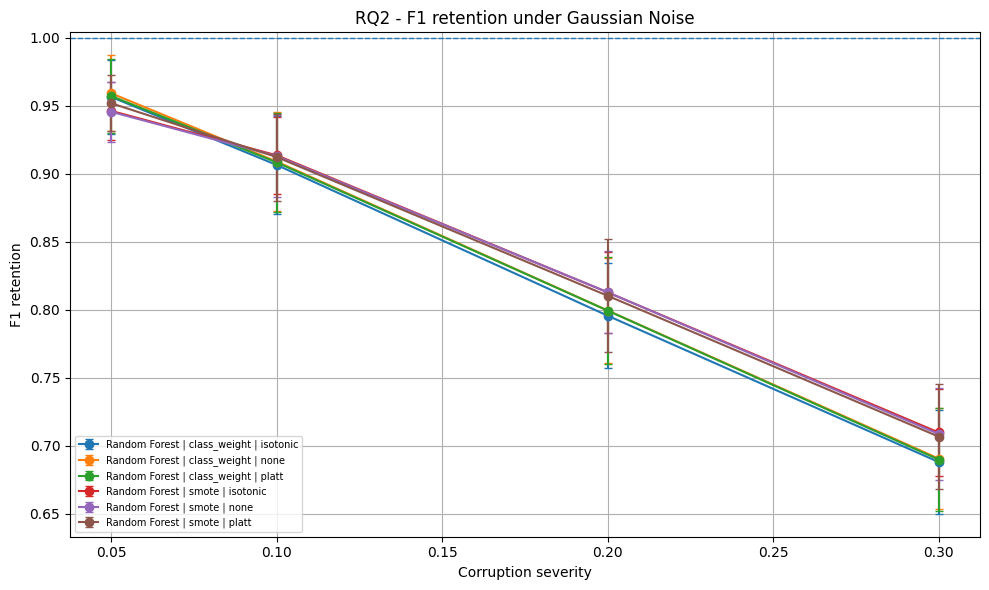

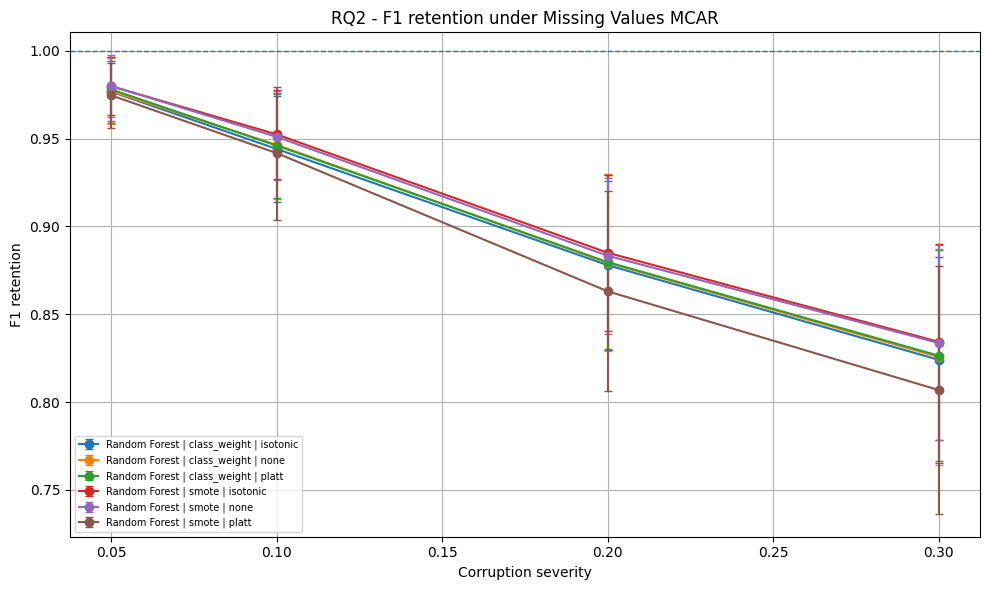

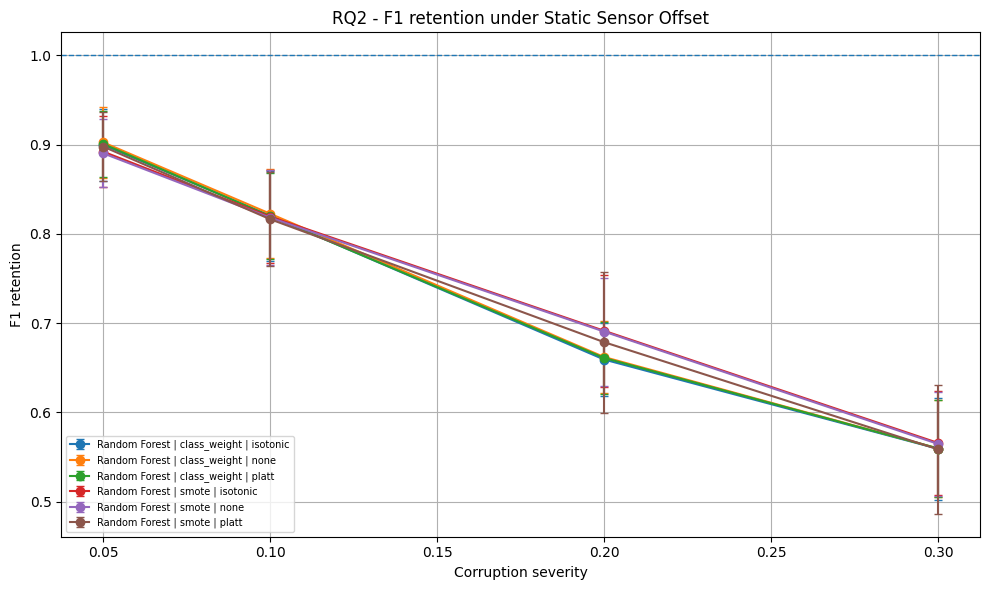

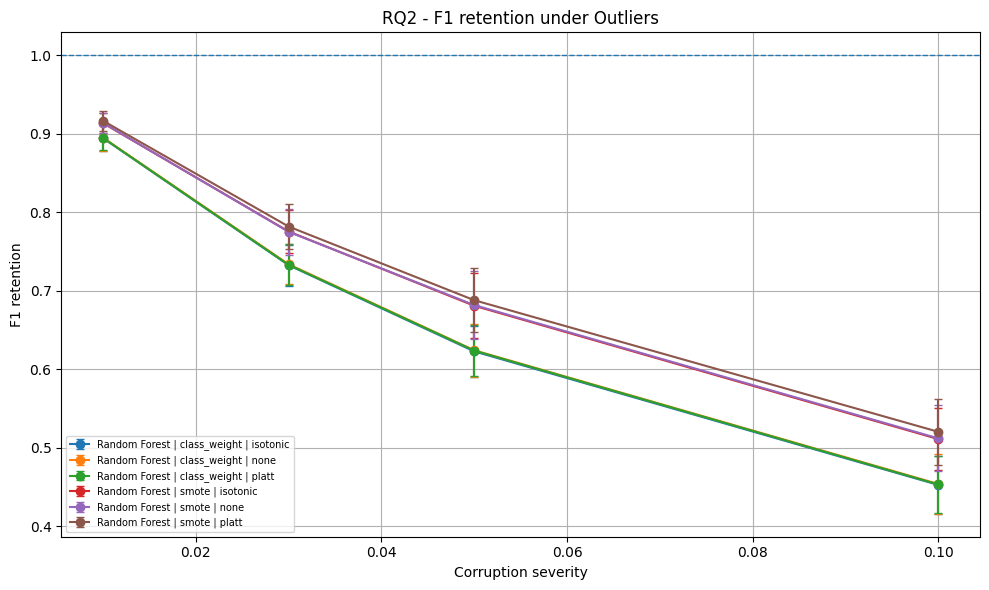

In [63]:
# Plot retention curves for top variants under each corruption condition
for condition in PERTURBATION_LEVELS:
    plt.figure(figsize=(10, 6))

    # Filter robustness results for this condition
    subset = robustness_by_level[robustness_by_level['Condition'] == condition]

    # Select top variants based on composite robustness
    top = robustness_summary.head(6)['Variant'].tolist()
    subset = subset[subset['Variant'].isin(top)]

    # Compute mean retention and std for error bars
    plot_data = (
        subset.groupby(['Variant', 'Level'], as_index=False)
        .agg(retention=('F1_Retention', 'mean'),
             retention_std=('F1_Retention', 'std'))
    )
    plot_data['retention_std'] = plot_data['retention_std'].fillna(0.0)

    # Plot retention curves
    for variant, g in plot_data.groupby('Variant'):
        g = g.sort_values('Level')
        plt.errorbar(
            g['Level'], g['retention'],
            yerr=g['retention_std'],
            marker='o', capsize=3, label=variant
        )

    plt.axhline(1.0, linestyle='--', linewidth=1)
    plt.xlabel('Corruption severity')
    plt.ylabel('F1 retention')
    plt.title(f'RQ2 - F1 retention under {condition}')
    plt.grid(True)
    plt.legend(fontsize=7)
    plt.tight_layout()

    plt.savefig(FIGURE_DIR / f"rq2_{condition.lower().replace(' ', '_')}_retention.png", dpi=300)
    plt.show()

**6. Heatmap of Condition‑Specific Robustness**

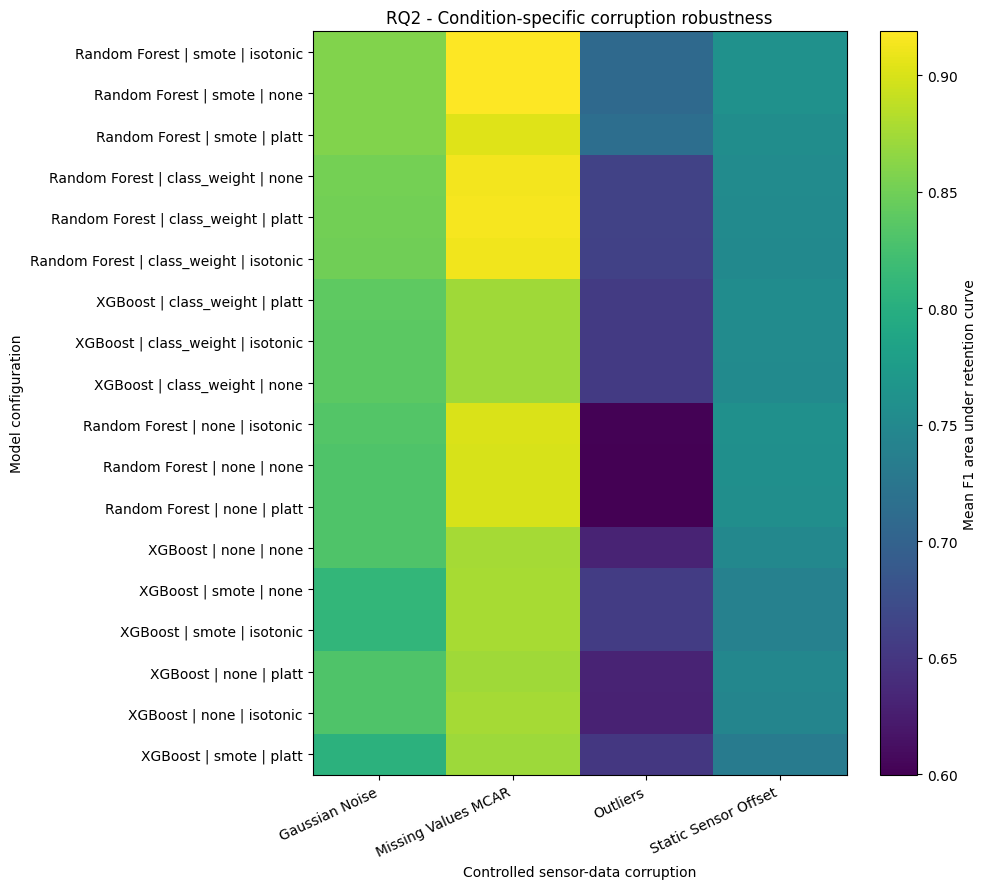

In [64]:
# Heatmap of mean AURetC per variant × corruption condition
condition_summary = (
    condition_auretc_df
    .groupby(['Variant', 'Condition'], as_index=False)
    .agg(F1_AURetC_Mean=('F1_AURetC', 'mean'))
)

heatmap = condition_summary.pivot(
    index='Variant',
    columns='Condition',
    values='F1_AURetC_Mean'
)

# Order rows by composite robustness
order = robustness_summary.sort_values(
    'Composite_Corruption_Robustness_Mean',
    ascending=False
)['Variant']
heatmap = heatmap.reindex(order)

plt.figure(figsize=(10, 9))
image = plt.imshow(heatmap.to_numpy(), aspect='auto')
plt.colorbar(image, label='Mean F1 area under retention curve')

plt.xticks(range(len(heatmap.columns)), heatmap.columns, rotation=25, ha='right')
plt.yticks(range(len(heatmap.index)), heatmap.index)

plt.xlabel('Controlled sensor-data corruption')
plt.ylabel('Model configuration')
plt.title('RQ2 - Condition-specific corruption robustness')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'rq2_overall_robustness_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## Candidate-Level Summary

This section aggregates repeated-run clean evaluation metrics across all 20 seeds to produce a candidate-level summary. It merges clean performance, latency, calibration, efficiency, and robustness metrics into a single table. This summary is consumed directly by Notebook 6 (RDRA) as the upstream evidence for reliability estimation and rank aggregation.


In [65]:
# Aggregate clean evaluation metrics across all 20 seeds
# Produces mean values for each metric per Variant
clean_summary = (
    clean_df.groupby(['Variant', 'Model', 'Strategy', 'Calibration'], as_index=False)
    .agg(
        # Predictive quality metrics
        Accuracy=('Accuracy', 'mean'),
        Precision=('Precision', 'mean'),
        Recall=('Recall', 'mean'),
        F1=('F1', 'mean'),
        ROC_AUC=('ROC_AUC', 'mean'),
        PR_AUC=('PR_AUC', 'mean'),
        Brier=('Brier', 'mean'),
        Log_Loss=('Log_Loss', 'mean'),
        ECE=('ECE', 'mean'),

        # Operational impact
        Operational_Cost=('Operational_Cost', 'mean'),

        # Training and calibration time
        Base_Model_Training_Time_Seconds=('Base_Model_Training_Time_Seconds', 'mean'),
        Calibration_Fit_Time_Seconds=('Calibration_Fit_Time_Seconds', 'mean'),
        Total_Configuration_Fit_Time_Seconds=('Total_Configuration_Fit_Time_Seconds', 'mean'),

        # Efficiency metrics (latency + throughput)
        Batch_Latency_Median_ms=('Batch_Latency_Median_ms', 'mean'),
        Batch_Latency_P95_ms=('Batch_Latency_P95_ms', 'mean'),
        Latency_Per_Sample_Median_ms=('Latency_Per_Sample_Median_ms', 'mean'),
        Single_Sample_Latency_Median_ms=('Single_Sample_Latency_Median_ms', 'mean'),
        Single_Sample_Latency_P95_ms=('Single_Sample_Latency_P95_ms', 'mean'),
        Throughput_Samples_Per_Second=('Throughput_Samples_Per_Second', 'mean'),

        # Model size
        Model_Size_MB=('Model_Size_MB', 'mean'),
    )
)

# Merge clean summary with robustness summary (AURetC + composite metrics)
# This produces the final candidate-level summary used by RDRA
candidate_summary = clean_summary.merge(robustness_summary, on='Variant', how='left')

candidate_summary.to_csv(OUTPUT_DIR/'07_candidate_summary.csv',index=False)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 300)
pd.set_option('display.max_rows', 200)

print(candidate_summary.sort_values('F1',ascending=False).head(10))

                              Variant          Model      Strategy Calibration  Accuracy  Precision    Recall        F1   ROC_AUC    PR_AUC     Brier  Log_Loss       ECE  Operational_Cost  Base_Model_Training_Time_Seconds  Calibration_Fit_Time_Seconds  Total_Configuration_Fit_Time_Seconds  \
14             XGBoost | none | platt        XGBoost          none       platt  0.972000   0.592297  0.823529  0.677265  0.975720  0.810519  0.012618  0.050526  0.007608            123.00                          0.407120                      0.006136                              0.413256   
12          XGBoost | none | isotonic        XGBoost          none    isotonic  0.972067   0.586338  0.826471  0.676655  0.969558  0.765946  0.012891  0.063557  0.006903            121.55                          0.407120                      0.001074                              0.408194   
13              XGBoost | none | none        XGBoost          none        none  0.971900   0.592073  0.821569  0.676022  

## RQ1 - Conventional vs Deployment-Oriented Baseline Ranking

This section compares conventional predictive-performance ranking (F1 and PR-AUC) with a deployment-oriented baseline ranking that incorporates five deployment dimensions: predictive quality, robustness, probability reliability, efficiency, and operational impact. It computes rank changes, Spearman/Kendall agreement, and produces a ranking comparison plot. These results form the motivation for RDRA in Notebook 6.


**1. Utility Functions for Min–Max Normalisation**

In [66]:
# Min-max normalisation for benefit metrics (higher = better)
def minmax_benefit(series):
    s = pd.Series(series, dtype=float)
    lo, hi = s.min(), s.max()

    # If all values identical, return 1 for all
    if np.isclose(lo, hi):
        return pd.Series(np.ones(len(s)), index=s.index)

    # Normalise to [0, 1]
    return (s - lo) / (hi - lo)

# Min-max normalisation for cost metrics (lower = better)
def minmax_cost(series):
    return 1.0 - minmax_benefit(series)

**2. Compute Conventional Ranking (F1 + PR-AUC)**

In [67]:
# Copy candidate summary for RQ1 analysis
rq1 = candidate_summary.copy()

# Conventional ranking based on F1 and PR-AUC
for col in ['F1', 'PR_AUC']:
    rq1[f'{col}_Rank'] = rq1[col].rank(ascending=False, method='average')

# Mean rank across F1 and PR-AUC
rq1['Conventional_Mean_Rank'] = rq1[['F1_Rank', 'PR_AUC_Rank']].mean(axis=1)

# Final conventional rank (1 = best)
rq1['Conventional_Rank'] = rq1['Conventional_Mean_Rank'].rank(
    ascending=True, method='min'
).astype(int)

**3. Compute Deployment-Oriented Baseline Scores**

In [68]:
# Deployment-oriented baseline scores across 5 dimensions

# Predictive quality (benefit)
rq1['Predictive_Quality_Score'] = (
    minmax_benefit(rq1['F1']) +
    minmax_benefit(rq1['PR_AUC'])
) / 2

# Robustness (benefit)
rq1['Robustness_Score'] = minmax_benefit(
    rq1['Composite_Corruption_Robustness_Mean']
)

# Probability reliability (cost → benefit)
rq1['Probability_Reliability_Score'] = (
    minmax_cost(rq1['Brier']) +
    minmax_cost(rq1['ECE'])
) / 2

# Efficiency (cost → benefit)
rq1['Efficiency_Score'] = (
    minmax_cost(rq1['Single_Sample_Latency_Median_ms']) +
    minmax_cost(rq1['Model_Size_MB'])
) / 2

# Operational impact (cost → benefit)
rq1['Operational_Score'] = minmax_cost(rq1['Operational_Cost'])

**4. Compute Deployment Baseline Rank**

In [69]:
# Combine all deployment dimensions
dims = [
    'Predictive_Quality_Score',
    'Robustness_Score',
    'Probability_Reliability_Score',
    'Efficiency_Score',
    'Operational_Score'
]

rq1['Deployment_Baseline_Score'] = rq1[dims].mean(axis=1)

# Deployment-oriented rank (1 = best)
rq1['Deployment_Baseline_Rank'] = rq1['Deployment_Baseline_Score'].rank(
    ascending=False, method='min'
).astype(int)

# Rank change relative to conventional ranking
rq1['Rank_Change_Deployment_Minus_Conventional'] = (
    rq1['Deployment_Baseline_Rank'] - rq1['Conventional_Rank']
)

**5. Rank Agreement (Spearman + Kendall)**

In [70]:
# Rank correlation between conventional and deployment rankings
rho, rho_p = spearmanr(rq1['Conventional_Rank'], rq1['Deployment_Baseline_Rank'])
tau, tau_p = kendalltau(rq1['Conventional_Rank'], rq1['Deployment_Baseline_Rank'])

**6. Save RQ1 Results**

In [71]:
# Sort by deployment rank for readability
rq1 = rq1.sort_values('Deployment_Baseline_Rank')

# Save full RQ1 table
rq1.to_csv(OUTPUT_DIR / '08_rq1_conventional_vs_deployment_ranking.csv', index=False)

# Identify winners
conventional_winner = rq1.sort_values('Conventional_Rank').iloc[0]['Variant']
deployment_winner = rq1.sort_values('Deployment_Baseline_Rank').iloc[0]['Variant']

# Summary table
rq1_summary = pd.DataFrame([{
    'Conventional_Winner': conventional_winner,
    'Deployment_Baseline_Winner': deployment_winner,
    'Winner_Changed': conventional_winner != deployment_winner,
    'Spearman_Rho': rho,
    'Spearman_p': rho_p,
    'Kendall_Tau': tau,
    'Kendall_p': tau_p,
}])

rq1_summary.to_csv(OUTPUT_DIR / '09_rq1_summary.csv', index=False)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 300)
pd.set_option('display.max_rows', 200)

# Print summary
print(rq1_summary)

print(
    rq1[
        [
            'Variant',
            'Conventional_Rank',
            'Deployment_Baseline_Rank',
            'Deployment_Baseline_Score',
            'Rank_Change_Deployment_Minus_Conventional'
        ]
    ].head(12)
)

      Conventional_Winner Deployment_Baseline_Winner  Winner_Changed  Spearman_Rho  Spearman_p  Kendall_Tau  Kendall_p
0  XGBoost | none | platt     XGBoost | none | platt           False      0.819454    0.000032     0.668933   0.000124
                                 Variant  Conventional_Rank  Deployment_Baseline_Rank  Deployment_Baseline_Score  Rank_Change_Deployment_Minus_Conventional
14                XGBoost | none | platt                  1                         1                   0.812372                                          0
13                 XGBoost | none | none                  2                         2                   0.810635                                          0
12             XGBoost | none | isotonic                  5                         3                   0.793256                                         -2
11        XGBoost | class_weight | platt                  6                         4                   0.751776                          

**7. Plot Conventional vs Deployment Ranking**

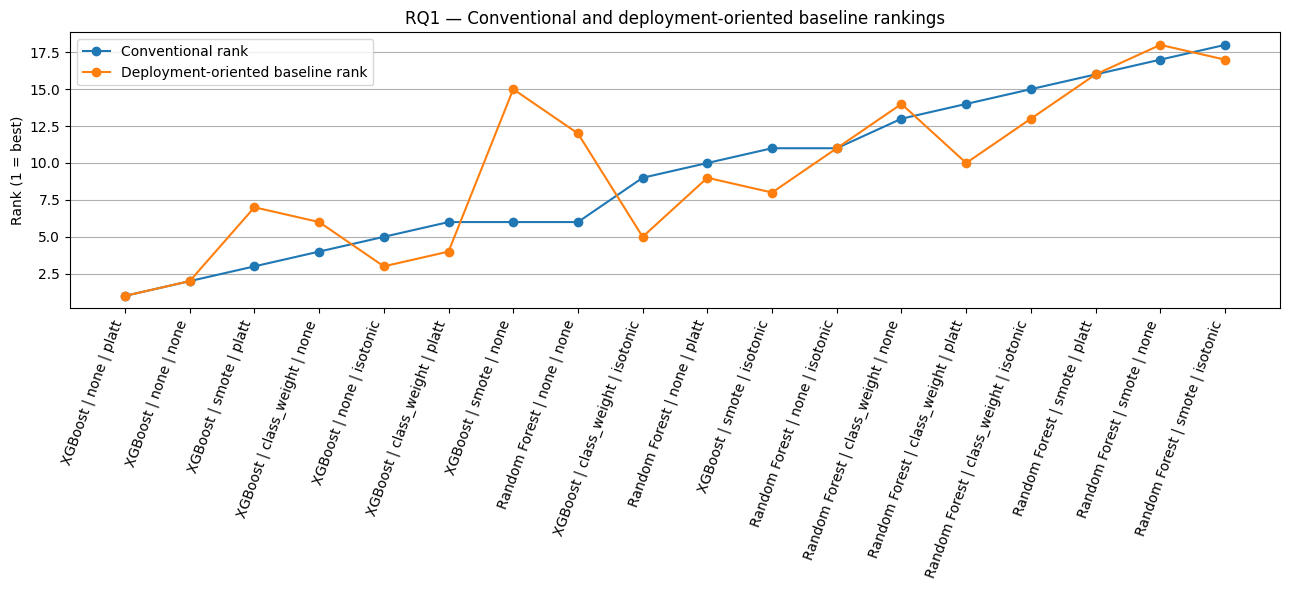

In [72]:
# Plot ranking comparison
plot_df = rq1.sort_values('Conventional_Rank')
x = np.arange(len(plot_df))

plt.figure(figsize=(13, 6))
plt.plot(x, plot_df['Conventional_Rank'], marker='o', label='Conventional rank')
plt.plot(x, plot_df['Deployment_Baseline_Rank'], marker='o', label='Deployment-oriented baseline rank')

plt.xticks(x, plot_df['Variant'], rotation=70, ha='right')
plt.ylabel('Rank (1 = best)')
plt.title('RQ1 — Conventional and deployment-oriented baseline rankings')
plt.grid(True, axis='y')
plt.legend()
plt.tight_layout()

plt.savefig(FIGURE_DIR / 'rq1_ranking_comparison.png', dpi=300)
plt.show()

## RQ3 - Pareto-Efficient Candidate Identification

This section identifies Pareto-efficient configurations across four deployment-relevant objectives: predictive quality (F1), corruption robustness, operational cost, and single-sample latency. It computes the Pareto front, visualises dominated vs efficient configurations, and evaluates preliminary fixed-weight deployment scenarios. These results feed into Notebook 3 and Notebook 6 (RDRA).


**1. Define Pareto Objectives**

In [73]:
# Objectives for Pareto analysis:
# - F1: maximise
# - Composite corruption robustness: maximise
# - Operational cost: minimise
# - Single-sample latency: minimise
PARETO_OBJECTIVES = {
    'F1': 'max',
    'Composite_Corruption_Robustness_Mean': 'max',
    'Operational_Cost': 'min',
    'Single_Sample_Latency_Median_ms': 'min',
}

**2. Dominance Function**

In [74]:
# Check if candidate a dominates candidate b
# a dominates b if:
# - a is no worse in all objectives
# - a is strictly better in at least one objective

def dominates(a, b, objectives):
    no_worse = True
    strict = False

    for col, direction in objectives.items():
        av, bv = float(a[col]), float(b[col])

        if direction == 'max':
            if av < bv:  # worse
                no_worse = False
                break
            if av > bv:  # strictly better
                strict = True
        else:  # direction == 'min'
            if av > bv:  # worse
                no_worse = False
                break
            if av < bv:  # strictly better
                strict = True

    return no_worse and strict

**3. Compute Pareto Mask**

In [75]:
# Compute boolean mask indicating Pareto-efficient candidates
def pareto_mask(df, objectives):
    rec = df.reset_index(drop=True)
    efficient = np.ones(len(rec), dtype=bool)

    for i in range(len(rec)):
        if not efficient[i]:
            continue
        for j in range(len(rec)):
            if i != j and dominates(rec.iloc[j], rec.iloc[i], objectives):
                efficient[i] = False
                break

    return efficient

**4. Apply Pareto Analysis**

In [76]:
# Apply Pareto mask to candidate summary
pareto_df = candidate_summary.copy()
pareto_df['Pareto_Efficient'] = pareto_mask(pareto_df, PARETO_OBJECTIVES)

# Sort: efficient first, then by F1
pareto_df = pareto_df.sort_values(['Pareto_Efficient', 'F1'], ascending=[False, False])

pareto_df.to_csv(OUTPUT_DIR / '10_rq3_pareto_candidates.csv', index=False)

**5. Display Pareto-Efficient Configurations**

In [77]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 300)
pd.set_option('display.max_rows', 200)

# Print number of Pareto-efficient configurations
print('Pareto-efficient configurations:', int(pareto_df['Pareto_Efficient'].sum()))

# Display key metrics for Pareto-efficient candidates
print(
    pareto_df[pareto_df['Pareto_Efficient']][[
        'Variant',
        'F1',
        'Composite_Corruption_Robustness_Mean',
        'Operational_Cost',
        'Single_Sample_Latency_Median_ms'
    ]]
)

Pareto-efficient configurations: 13
                                    Variant        F1  Composite_Corruption_Robustness_Mean  Operational_Cost  Single_Sample_Latency_Median_ms
14                   XGBoost | none | platt  0.677265                              0.770768            123.00                         7.106265
12                XGBoost | none | isotonic  0.676655                              0.770388            121.55                         6.353023
13                    XGBoost | none | none  0.676022                              0.771590            124.05                         6.615234
9         XGBoost | class_weight | isotonic  0.654247                              0.779660            131.95                         9.820655
10            XGBoost | class_weight | none  0.653949                              0.779242            132.05                         7.221460
11           XGBoost | class_weight | platt  0.649438                              0.780461            132

**6. Plot F1 vs Operational Cost**

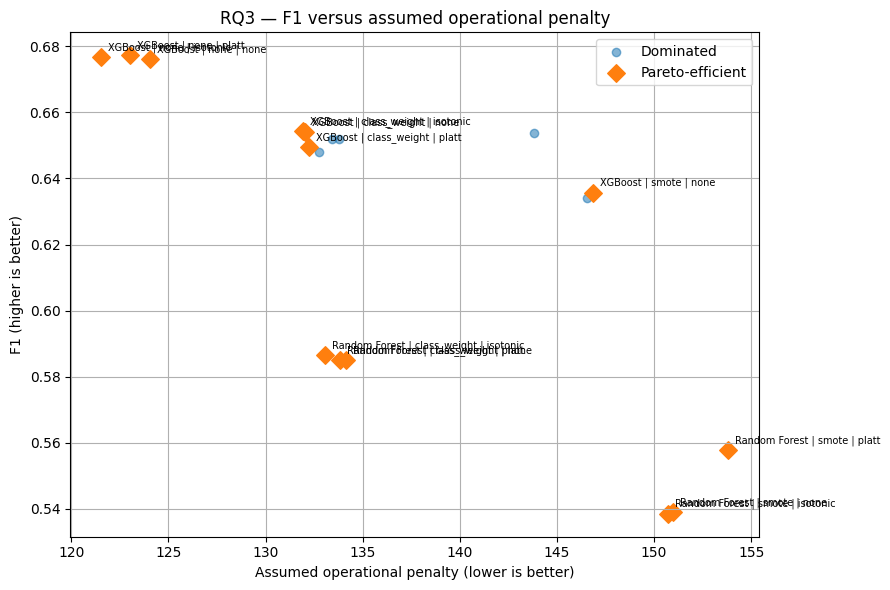

In [78]:
# Scatter plot: F1 vs operational cost
non = pareto_df[~pareto_df['Pareto_Efficient']]
front = pareto_df[pareto_df['Pareto_Efficient']]

plt.figure(figsize=(9, 6))
plt.scatter(non['Operational_Cost'], non['F1'], alpha=.55, label='Dominated')
plt.scatter(front['Operational_Cost'], front['F1'], marker='D', s=80, label='Pareto-efficient')

# Annotate Pareto front
for _, r in front.iterrows():
    plt.annotate(r['Variant'], (r['Operational_Cost'], r['F1']),
                 xytext=(5, 5), textcoords='offset points', fontsize=7)

plt.xlabel('Assumed operational penalty (lower is better)')
plt.ylabel('F1 (higher is better)')
plt.title('RQ3 — F1 versus assumed operational penalty')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(FIGURE_DIR / 'rq3_pareto_f1_vs_cost.png', dpi=300)
plt.show()

**7. Plot Robustness vs Latency**

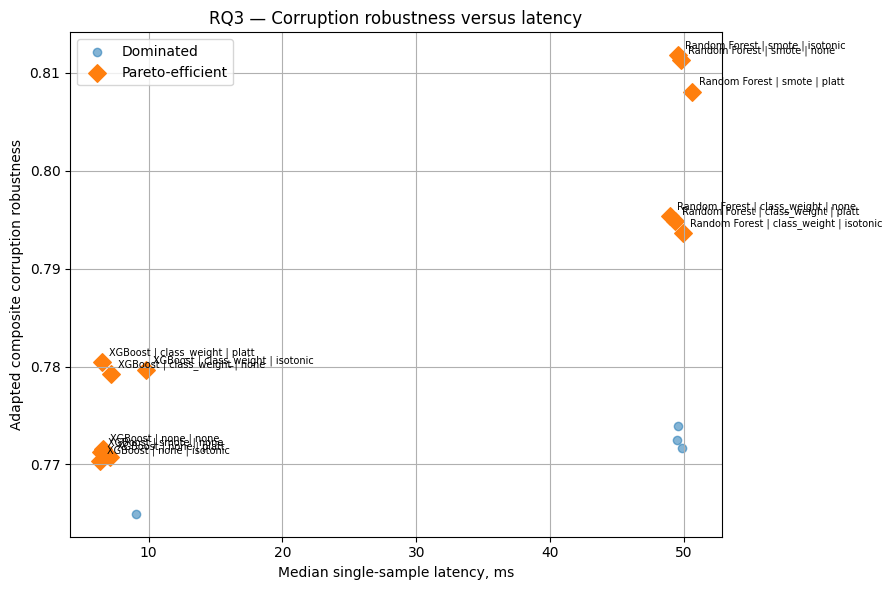

In [79]:
# Scatter plot: corruption robustness vs single-sample latency
plt.figure(figsize=(9, 6))
plt.scatter(non['Single_Sample_Latency_Median_ms'], non['Composite_Corruption_Robustness_Mean'],
            alpha=.55, label='Dominated')
plt.scatter(front['Single_Sample_Latency_Median_ms'], front['Composite_Corruption_Robustness_Mean'],
            marker='D', s=80, label='Pareto-efficient')

# Annotate Pareto front
for _, r in front.iterrows():
    plt.annotate(
        r['Variant'],
        (r['Single_Sample_Latency_Median_ms'], r['Composite_Corruption_Robustness_Mean']),
        xytext=(5, 5), textcoords='offset points', fontsize=7
    )

plt.xlabel('Median single-sample latency, ms')
plt.ylabel('Adapted composite corruption robustness')
plt.title('RQ3 — Corruption robustness versus latency')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(FIGURE_DIR / 'rq3_pareto_robustness_vs_latency.png', dpi=300)
plt.show()

## Preliminary Fixed-Weight Baseline Scenarios

This subsection evaluates three fixed-weight deployment scenarios (Safety-Focused, Resource-Constrained Edge, Balanced Deployment). These are preliminary baselines used only for comparison; the full preference-sensitive method is implemented in Notebook 3.


**1. Define Scenario Weights**

In [80]:
# Preliminary fixed-weight baseline only
scenario_weights = {
    'Safety_Focused': {
        'Predictive_Quality_Score': .25,
        'Robustness_Score': .25,
        'Probability_Reliability_Score': .10,
        'Efficiency_Score': .05,
        'Operational_Score': .35
    },
    'Resource_Constrained_Edge': {
        'Predictive_Quality_Score': .15,
        'Robustness_Score': .15,
        'Probability_Reliability_Score': .10,
        'Efficiency_Score': .45,
        'Operational_Score': .15
    },
    'Balanced_Deployment': {
        'Predictive_Quality_Score': .20,
        'Robustness_Score': .20,
        'Probability_Reliability_Score': .20,
        'Efficiency_Score': .20,
        'Operational_Score': .20
    },
}

# Merge Scenario Base with Pareto Flags
scenario_base = rq1.merge(
    pareto_df[['Variant', 'Pareto_Efficient']],
    on='Variant',
    how='left'
)

**2. Compute Scenario Scores and Winners**

In [81]:
rows = []

for scenario, weights in scenario_weights.items():
    score_col = f'{scenario}_Score'

    # Weighted score across deployment dimensions
    scenario_base[score_col] = sum(
        scenario_base[col] * w for col, w in weights.items()
    )

    # Prefer Pareto-efficient candidates when available
    eligible = scenario_base[scenario_base['Pareto_Efficient']].copy()
    if eligible.empty:
        eligible = scenario_base.copy()

    # Select top candidate
    winner = eligible.sort_values(score_col, ascending=False).iloc[0]

    rows.append({
        'Scenario': scenario,
        'Recommended_Variant': winner['Variant'],
        'Scenario_Score': winner[score_col],
        'F1': winner['F1'],
        'Recall': winner['Recall'],
        'Composite_Corruption_Robustness': winner['Composite_Corruption_Robustness_Mean'],
        'Operational_Cost': winner['Operational_Cost'],
        'Single_Sample_Latency_Median_ms': winner['Single_Sample_Latency_Median_ms'],
        'Model_Size_MB': winner['Model_Size_MB'],
        'Brier': winner['Brier'],
        'Pareto_Efficient': bool(winner['Pareto_Efficient']),
    })

preliminary_scenario_recommendations = pd.DataFrame(rows)
preliminary_scenario_recommendations.to_csv(
    OUTPUT_DIR / '11_rq3_preliminary_fixed_weight_baseline.csv',
    index=False
)

print(preliminary_scenario_recommendations)

                    Scenario     Recommended_Variant  Scenario_Score        F1    Recall  Composite_Corruption_Robustness  Operational_Cost  Single_Sample_Latency_Median_ms  Model_Size_MB     Brier  Pareto_Efficient
0             Safety_Focused  XGBoost | none | platt        0.763989  0.677265  0.823529                         0.770768            123.00                         7.106265       0.839560  0.012618              True
1  Resource_Constrained_Edge   XGBoost | none | none        0.857264  0.676022  0.821569                         0.771590            124.05                         6.615234       0.838991  0.012628              True
2        Balanced_Deployment  XGBoost | none | platt        0.812372  0.677265  0.823529                         0.770768            123.00                         7.106265       0.839560  0.012618              True


## SHAP Explainability Demonstration

This section generates a SHAP summary plot for the top-ranked deployment-oriented XGBoost candidate. It uses the representative model stored earlier (seed 42) and computes SHAP values on a sample of the test set. The output is a global explainability visualisation showing feature impact on predicted failure probability.


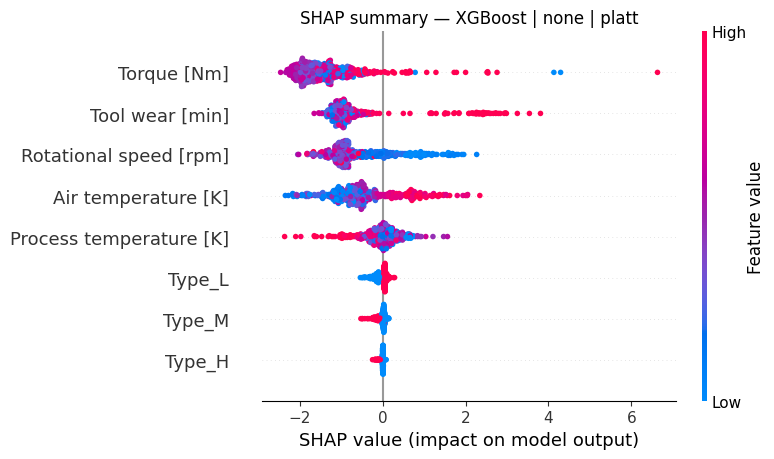

SHAP candidate: XGBoost | none | platt


In [82]:
import shap

# Select the highest-ranked deployment-oriented XGBoost variant
order = rq1.sort_values('Deployment_Baseline_Rank')['Variant'].tolist()
selected_variant = next((v for v in order if v.startswith('XGBoost')), None)

if selected_variant is None:
    print('No XGBoost candidate available.')

else:
    # Retrieve representative model (seed 42)
    selected = representative_models[selected_variant]
    model = selected['model']

    # Extract preprocessing and classifier components
    pre = model.named_steps['preprocessor']
    clf = model.named_steps['model']

    # Sample up to 500 test rows for SHAP computation
    X_example = selected['X_test'].sample(
        n=min(500, len(selected['X_test'])),
        random_state=SEEDS[0]
    )

    # Apply preprocessing pipeline
    X_transformed = pre.transform(X_example)

    # Build feature name list (numeric + encoded categorical)
    feature_names = (
        list(numeric_features)
        + list(pre.named_transformers_['cat']
               .named_steps['encoder']
               .get_feature_names_out(categorical_features))
    )

    # SHAP TreeExplainer for XGBoost
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_transformed)

    # XGBoost sometimes returns list of arrays → use last element
    if isinstance(shap_values, list):
        shap_values = shap_values[-1]

    # SHAP summary plot (global feature importance)
    shap.summary_plot(
        shap_values,
        X_transformed,
        feature_names=feature_names,
        show=False
    )

    plt.title(f'SHAP summary — {selected_variant}')
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / 'explainability_shap_summary.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

    print('SHAP candidate:', selected_variant)

## Notebook 1 Summary

In [84]:
# Automatic report
framework_report={
    'Research_Objective':'Develop and validate a software-level, deployment-oriented evaluation and decision methodology for predictive-maintenance model and pipeline configurations.',
    'AI4I_Study_Role':'Tabular machine-failure classification proof of concept.',
    'RQ1_Conventional_Winner':conventional_winner,
    'RQ1_Deployment_Baseline_Winner':deployment_winner,
    'RQ1_Winner_Changed':bool(rq1_summary.iloc[0]['Winner_Changed']),
    'RQ1_Spearman_Rho':float(rq1_summary.iloc[0]['Spearman_Rho']),
    'RQ1_Kendall_Tau':float(rq1_summary.iloc[0]['Kendall_Tau']),
    'RQ2_Best_Adapted_Composite_Corruption_Robustness':robustness_summary.iloc[0]['Variant'],
    'RQ2_Best_Adapted_Composite_Score':float(robustness_summary.iloc[0]['Composite_Corruption_Robustness_Mean']),
    'RQ3_Pareto_Efficient_Count':int(pareto_df['Pareto_Efficient'].sum()),
    'RQ3_Preliminary_Fixed_Weight_Recommendations':preliminary_scenario_recommendations[['Scenario','Recommended_Variant']].to_dict(orient='records'),
    'Operational_Cost_Assumption':'Penalty score with FP=1 and FN=10; not a monetary cost.',
    'Robustness_Method_Status':'The adapted composite corruption-robustness score is secondary. Condition-level retention, worst-case retention and Notebook 3 sensitivity analyses remain primary.',
    'Decision_Method_Status':'Equal-weight deployment scoring and fixed scenarios are baselines. The final constraint- and preference-aware method is implemented in Notebook 3.',
    'Latency_Interpretation':'Latency is measured in the current software environment and is comparative rather than hardware-certified.',
    'Explainability_Interpretation':'SHAP is a representative demonstration for one seed and one selected XGBoost configuration.',
    'Important_Limitation':'AI4I is tabular rather than temporal. Static sensor offset must not be described as gradual temporal drift.',
}

with open(OUTPUT_DIR/'12_framework_report.json','w',encoding='utf-8') as f:
    json.dump(framework_report,f,indent=2)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 300)
pd.set_option('display.max_rows', 200)

print(pd.DataFrame({'Item':list(framework_report.keys()),'Value':[str(v) for v in framework_report.values()]}))

                                                Item                                              Value
0                                 Research_Objective  Develop and validate a software-level, deploym...
1                                    AI4I_Study_Role  Tabular machine-failure classification proof o...
2                            RQ1_Conventional_Winner                             XGBoost | none | platt
3                     RQ1_Deployment_Baseline_Winner                             XGBoost | none | platt
4                                 RQ1_Winner_Changed                                              False
5                                   RQ1_Spearman_Rho                                 0.8194543709875155
6                                    RQ1_Kendall_Tau                                 0.6689328505057632
7   RQ2_Best_Adapted_Composite_Corruption_Robustness                   Random Forest | smote | isotonic
8                   RQ2_Best_Adapted_Composite_Score            